# ASTR 797 Spring 2026 - Homework 2.b

In this lab we will be performing surface photometry of a nearby spiral galaxy.

This lab will be done via a mixture of python commands using the photutils aperture photometry package (https://photutils.readthedocs.io/en/stable/aperture.html) and the photutils isophote fitting package (https://photutils.readthedocs.io/en/stable/isophote.html).  We will also be using imexam and ds9.

In this lab you will learn how to do the following things:
* estimate initial guesses for input parameters to an isophotal fitting code using ds9;
* fit elliptical isophotes;
* use photometry within these isophotes to measure the radial profile of various parameters;
* compute the radius within which half the total light is contained.  This is called the effective radius.


In [2]:
#import 
from astropy.stats import sigma_clipped_stats
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.io import fits
import glob
import os
from scipy.stats import scoreatpercentile
import astropy.units as u
from scipy import stats

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import pyplot as plt
import numpy as np
from matplotlib import colors


from astropy.nddata import CCDData
#from ccdproc import ImageFileCollection, Combiner, combine
from ccdproc import wcs_project

### Some functions to display the images and overplot the stars

In [3]:
def imdisplay(image, v1perc=10, v2perc=95, logscale=True):
    '''
    display an image 
    OPTIONAL KEYWORD PARAMETERS
    v1perc: one end of the colormap assigned to the v1perc percent lowest flux 
    v2perc: the other end of the colormap assigned to the v2perc percent highest flux    
    '''
    # make sure image is an np array
    nimage = np.array(image)
    # determine the pixel values at the 10th and 95th percentile
    v1 = scoreatpercentile(nimage,v1perc)
    v2 = scoreatpercentile(nimage,v2perc)
    # display using imshow
    #
    # you can play with alternate cmaps in the function below, such as "viridis" or "gray"
    # The 'gray_r' color map reverses the color-scale so that dark display pixels are the brightest in the image
    #
    # vmin and vmax set the min and max pixel values that
    # will be mapped to the extremes of the colormap
    print(v1,v2)
    if (logscale):
        im = ax.imshow(nimage,cmap='gray_r',aspect='equal',norm=colors.LogNorm(vmin=v1,vmax=v2),origin='lower')
    else:
        im = ax.imshow(nimage,cmap='gray_r',aspect='equal',vmin=v1,vmax=v2,origin='lower')
        
    cbar = fig.colorbar(im, ax=ax, fraction=0.04)
    cbar.ax.set_ylabel('counts')
    return fig,ax
    #fig.colorbar(fraction=.08)

In [4]:
#***************
#put your data directory here
datadir = 'C:/Users/Arish/Astr797_Hw/Hw2_corrections/Astr797_Galaxy_Fits_files'
os.chdir(datadir)

# problem 2.b.i
## Display the image in DS9

SAOimage DS9 is a popular and easy to use image viewer.  There are various tutorials at https://sites.google.com/cfa.harvard.edu/saoimageds9/documentation?authuser=0 .

Here is another third party tutorial https://astrobites.org/2011/03/09/how-to-use-sao-ds9-to-examine-astronomical-images/ 

In the following description I will refer to menu choices as those at the top of the screen or window.  I will refer to buttons as the double line of buttons right above where the image is displayed.  I will refer to sub buttons with **button1**->**button2**

1. In DS9 open `frame-r-005079-4-0050.fits`
2. Under the **scale** button choose **log** and **zscale**.  In the Menu bar choose Scale->Scale parameters.  In the "high" box choose 10.
3. Use the right mouse button to change the stretch on the image.  You may need to select the **edit**->**none** or **edit**->**colorbar** button for this to work.


You can also display the iamge using the command below

-0.03228759765625 0.451171875


Text(0.5, 1.0, 'NGC 4474')

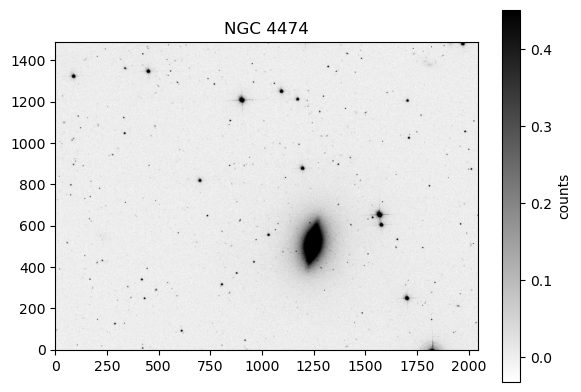

In [16]:
imname = 'frame-r-004381-1-0111.fits'
galname = 'NGC 4474'
data = {}
header = {}
fig,ax = plt.subplots(figsize=(6,6))
data[galname],header[galname] = fits.getdata(imname, header=True)
imdisplay(data[galname],v1perc=10,v2perc=99.5,logscale=False)

plt.title(galname)

## estimate initial guesses for ellipse parameters 
The `photutils` package that we will be using for doing our photometry requires initial guesses for the center, semi-major axis, ellipticity, and position angle.  We will measure the center using DS9 on the background subtracted images.
* xcen, ycen: What you think the center is by using the cursor on ds9

We will measure the ellipse parameters by plotting guess ellipses on the image in one of the cells below.  We can't do this on DS9 because it defines the PA with respect to the N-E cardinal directions and not with respect to pixel directions.  For these images the two are not aligned.
* semi-major axis (smaja), ellipticity (ellip), PA: For these items change the smaja and the semi-minor axis (smina) as well as the PA until your ellipse matches where the brighter part of the galaxy is.  

For each galaxy, provide these intial guesses.  I will be storing these as a python dictionary for each galaxy.

These guesses do not need to be super precise but they need to be in the right ballpark.

<font color='red'> next time display initial guess to check answer.  Then display all fitting ellipses in following problem.</font>

## fit elliptical isophotes and measure the radial profiles for various ellipse paramters

We will now use the `photutils.isophot()` task to fit elliptical isophotes (https://photutils.readthedocs.io/en/stable/isophote.html).  An "isophote" is a line of constant surface brightness, akin to a countour on a topographical map.  To get a visual representation of an isophote do the following:
* open one of the background subtracted images in ds9 and dislay it in log scale
* in the analysis menu open "contour parameters" and set the number of countours to 10.  Then hit `Generate` and then `Apply`

The green lines on your image connect pixels of identical flux.  Since the pixels have the same area within a given image, these lines therefore connect points of constant surface brightness.

The `photutils.isophote()` code that we will be using fits ellipses to the isophotes.

In [17]:
from photutils.isophote import (EllipseGeometry,build_ellipse_model)
from photutils.aperture import EllipticalAperture

#define an empty dictionary that will contain the EllipseGeometry instance
geometry = {}

#initialize the dictionary containing the intial parameters for the ellipse fitting
initparams = {}

 We must provide the elliptical isophote fitter with an initial ellipse to be fitted. This ellipse geometry is defined with the **EllipseGeometry** class. Here we’ll define an initial ellipse from our answer to problem 2.

In [34]:
#initiparams is a dictionary which contains an entry for each galaxy.  That dictionary in turns points to another dictionary with the parameters.
galname = 'NGC 4474'
initparams[galname] = {}
initparams[galname]['xcen'] = 1245
initparams[galname]['ycen'] = 518
initparams[galname]['smaja'] = 130
initparams[galname]['smina'] = 80.
initparams[galname]['ellip'] = initparams[galname]['smina'] / initparams[galname]['smaja']
initparams[galname]['PA'] =80

-0.002521514892578125 0.451171875


Text(0.5, 1.0, 'NGC 4474')

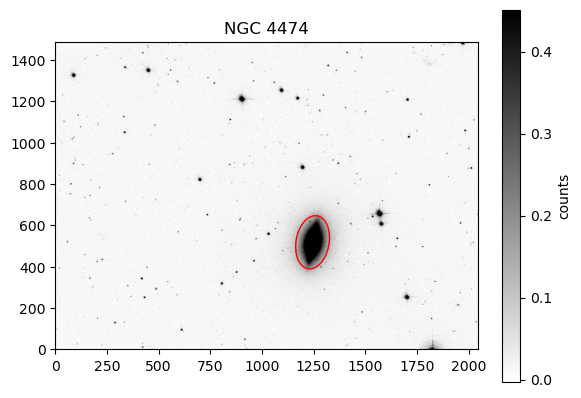

In [35]:
#set up the EllipseGeometry instance with the right initial guess parameters
geometry[galname] = EllipseGeometry(x0 = initparams[galname]['xcen'], 
                                      y0 = initparams[galname]['ycen'],
                                      sma = initparams[galname]['smaja'],
                                      eps = initparams[galname]['ellip'],
                                      pa = (initparams[galname]['PA']) * np.pi/180)   #convert into radians

#make an aperture to overplot so that we can check if it makes sense
aper = EllipticalAperture((geometry[galname].x0, geometry[galname].y0), geometry[galname].sma, 
                          geometry[galname].sma * (geometry[galname].eps), geometry[galname].pa)

#plot our image
fig,ax = plt.subplots(figsize=(6,6))
imdisplay(data[galname],v1perc=40,v2perc=99.5,logscale=False)
aper.plot(color='red')
plt.title(galname)

make a subroutine to plot our outputs of ellipse fitting

In [36]:
def plotellipse(isolist):
    plt.figure(figsize=(8, 8))
    plt.subplots_adjust(hspace=0.35, wspace=0.35)

    #plot the semi-major axis vs. the ellipticity
    plt.subplot(2, 2, 1)
    plt.errorbar(isolist.sma, isolist.eps, yerr=isolist.ellip_err,
                 fmt='o', markersize=4)
    plt.xlabel('Semimajor Axis Length (pix)')
    plt.ylabel('Ellipticity')

    #plot the semi-major axis vs. the PA
    plt.subplot(2, 2, 2)
    plt.errorbar(isolist.sma, isolist.pa / np.pi * 180.0,
                 yerr=isolist.pa_err / np.pi * 80.0, fmt='o', markersize=4)
    plt.xlabel('Semimajor Axis Length (pix)')
    plt.ylabel('PA (deg)')

    #plot the semi-major axis vs. the x center of that ellipse
    plt.subplot(2, 2, 3)
    plt.errorbar(isolist.sma, isolist.x0, yerr=isolist.x0_err, fmt='o',
                 markersize=4)
    plt.xlabel('Semimajor Axis Length (pix)')
    plt.ylabel('x0')

    #plot the semi-major axis vs. the y center of that ellipse
    plt.subplot(2, 2, 4)
    plt.errorbar(isolist.sma, isolist.y0, yerr=isolist.y0_err, fmt='o',
                 markersize=4)
    plt.xlabel('Semimajor Axis Length (pix)')
    plt.ylabel('y0')

Next, we create an instance of the Ellipse class, inputting the data to be fitted and the initial ellipse geometry object:

In [37]:
from photutils.isophote import Ellipse

#initialize dictionary for ellipse fitting
ellipse = {}
isolist = {}

The values computed by the fitting process are the attributes at this table https://photutils.readthedocs.io/en/stable/api/photutils.isophote.Isophote.html#photutils.isophote.Isophote

I will do the first galaxy for you and you will need to do the other three

In [38]:
#this will do the fitting of the isophotes by making an instance of the Ellipse class
#It then fits the data using the initial guesses we computed above
galname = 'NGC 4474'
ellipse[galname] = Ellipse(data[galname], geometry[galname])
isolist[galname] = ellipse[galname].fit_image()

-0.03228759765625 16.50165312498575


Text(0.5, 1.0, 'NGC 4474')

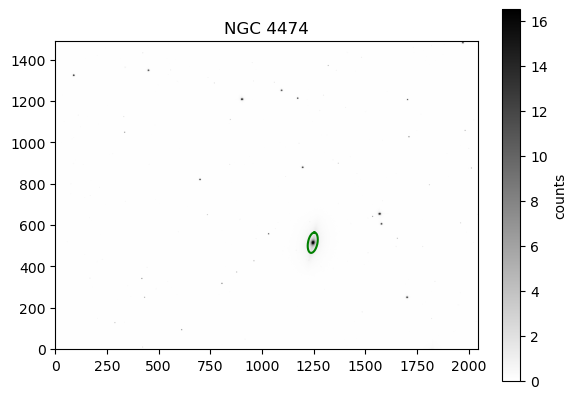

In [42]:
#plot elliptical apertures from fitting

#plot our image
fig,ax = plt.subplots(figsize=(6,6))
imdisplay(data[galname],v1perc=10,v2perc=99.99,logscale=False)


#model_image = build_ellipse_model(data[galname].shape, isolist)
#residual = data - model_image

smas = np.linspace(50, 500, 1)
for sma in smas:
    iso = isolist[galname].get_closest(sma)
    x, y, = iso.sampled_coordinates()
    ax.plot(x, y, color='green')

    
plt.title(galname)

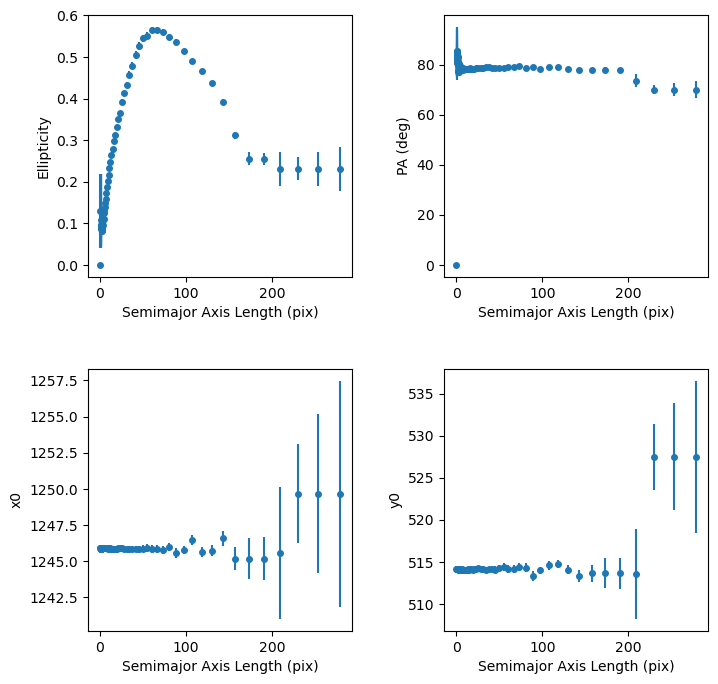

In [43]:
#this puts the output into a table containing every ellipse.   
#You can comment this first line out if you don't want it always to print out.
#print(isolist[galname].to_table())

#make a set of plots that show some attributes of every ellipse.
plotellipse(isolist[galname])

Now plot the surface brightness profile, measured within each elliptical aperture.

I also need to correct the profile for inclination.  From the written solution sets, $I_{corr}$ = $I_{obs} \cos i$, where $i = \cos^{-1} (b/a)$.  Therefore $I_{corr}$ = $I_{obs} (b/a)$.  

The photutils package returns various parameters about each ellipse, defined at https://photutils.readthedocs.io/en/stable/api/photutils.isophote.IsophoteList.html#photutils.isophote.IsophoteList .  In addition to the semi-major axis, it also returns the ellipticity, $\epsilon = 1-b/a$.  Therefore $b/a = 1-\epsilon$ and $I_{corr}$ = $I_{obs} (1-\epsilon)$.


In [44]:
#initialize dictionary for half-light radii
rhalfpix = {}
rhalfasec = {}

Text(0.5, 1.0, 'NGC 4474')

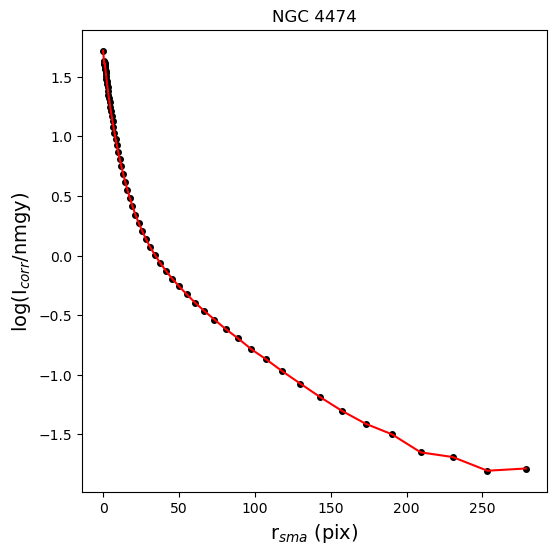

In [46]:
galname = 'NGC 4474'
plt.figure(figsize=(6, 6))

#isolist.intens is the mean ellipticity along the isophote path.  The 
#description of all the info for every isolist is at 

#I need to correct the profile to face on inclination by multiplying by the cosine of the inclination angle.
Icorr = isolist[galname].intens * (1 - isolist[galname].eps)

#plot the semi-major axis vs. the mean ellipticity along the isophote path.
plt.errorbar(isolist[galname].sma, np.log10(Icorr), 
             fmt='o', markersize=4, color='black')
plt.errorbar(isolist[galname].sma, np.log10(Icorr), 
             fmt='-', markersize=4, color='red')


plt.xlabel(r'r$_{sma}$ (pix)',fontsize=14)
plt.ylabel(r'log(I$_{corr}$/nmgy)',fontsize=14)
plt.title(galname)


# problem 2.b.ii

We need to fit a profile to this galaxy.  As we learned in class, an exponential should appear as a straight line in this plot.  While this is true at $r\gtrsim 100$~pix, it is not true at smaller radii, which look more like an $n=4$ profile.  There are many ways to accomplish this fit.  Professionally, it is usually the case that two models are simultaneously fit using a set of initial guesses.  However, since we have an ample region of the galaxy that appears to be dominated by an exponential and because the galaxy is well-resolved, I will perform this decomposition in the following way:

1. fit a straight line to the above figure at $r>100$~pix to determine the exponential scale length.
2. use scipy.optimize.curve_fit to fit an n=4 sersic bulge added to the exponential fit that we determined from step 1.

It turns out that you need to remove the central 5 pixels to get a good fit for the bulge.  This is likely because the atmospheric seeing smears out the central part of the profile and makes it deviate from an n=4 profile.


In [47]:
def sersic_plus_disk(r, Re, Ie, n):
    '''For a given value of the effective radius and Intensity 
    at the effective radius, and sersic n, return the intensity of the fit
    
    This also adds to the profile the exponential disk
    
    '''
    #n=4
    bn = 1.999*n - 0.237
    Ibulge = Ie * np.exp(-bn * ((r/Re)**(1/n)-1))

    #do the inelegant thing and hardcode the exponential coefficients 
    #coeff1 = -0.3597
    #coeff0 = -0.004767
    
    #do the risky think and use global variables to avoid having to pass a non-fitted parameter to the function
    coeff1 = coeff[1]
    coeff0 = coeff[0]
    Itot = Ibulge + 10**(coeff[1] + coeff[0] * r)
    
    #add to this the best fit value of the exponential
    return Itot

In [48]:
def sersic_plus_n4(r, Re, Ie):
    '''For a given value of the effective radius and Intensity 
    at the effective radius, return the intensity of the fit.
    Assume n=4
    
    This also adds to the profile the exponential disk
    
    '''
    n=4
    bn = 1.999*n - 0.237
    Ibulge = Ie * np.exp(-bn * ((r/Re)**(1/n)-1))

    #do the inelegant thing and hardcode the exponential coefficients 
    #coeff1 = -0.3597
    #coeff0 = -0.004767
    
    #do the risky think and use global variables to avoid having to pass a non-fitted parameter to the function
    coeff1 = coeff[1]
    coeff0 = coeff[0]
    Itot = Ibulge + 10**(coeff[1] + coeff[0] * r)
    
    #add to this the best fit value of the exponential
    return Itot

log10(I0) =  -0.21086398898437525 , rexp =  68.09995630621867
Re =  16.84388978295216 , Ie =  2.842238574342824 , n =  2.0893331688420846
Re =  31.717166471665077 , Ie =  0.9406379402409765 , n fixed at 4


Text(0.5, 1.0, 'NGC 4474')

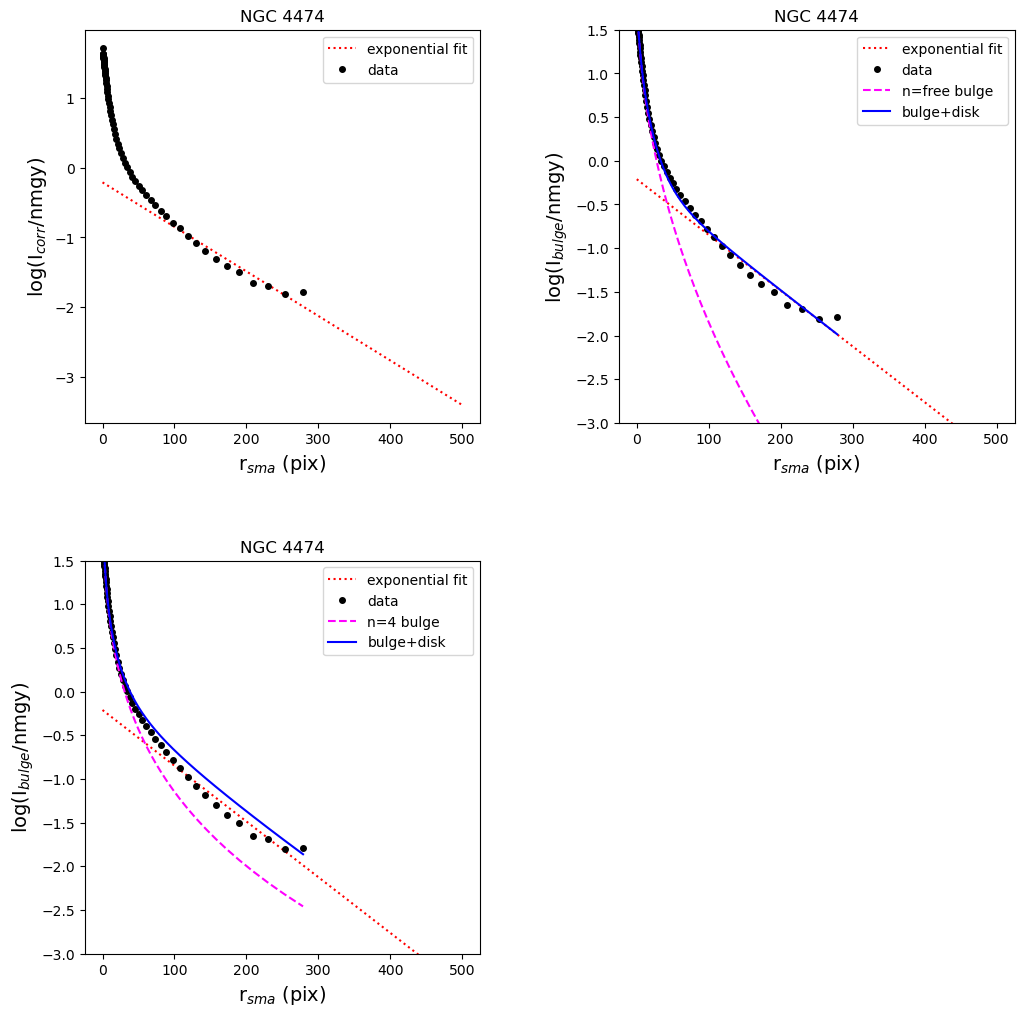

In [50]:
from scipy.optimize import curve_fit as cf

#select the region of the profile that is an exponential
expflag = isolist[galname].sma > 80

#fit the polynomial
coeff = np.polyfit(isolist[galname].sma[expflag], np.log10(Icorr[expflag]),1)
lgI0disk = coeff[1]

#remember that the coefficient when fitting in log space is log10(e^-1)/rexp, 
#where rexp is the half-light radius
rexp = np.log10(np.exp(-1.)) / coeff[0]
print('log10(I0) = ', coeff[1], ', rexp = ', rexp)

plt.figure(figsize=(12, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.35)

#plot the profile with a fit
plt.subplot(2, 2, 1)

#plot the semi-major axis vs. the mean ellipticity along the isophote path.
plt.errorbar(isolist[galname].sma, np.log10(Icorr), 
             fmt='o', markersize=4, color='black', label='data')

x = np.linspace(0,500,2)
y = lgI0disk + coeff[0] * x
plt.plot(x,y,'r:', label = 'exponential fit')

plt.xlabel(r'r$_{sma}$ (pix)',fontsize=14)
plt.ylabel(r'log(I$_{corr}$/nmgy)',fontsize=14)
plt.title(galname)
plt.legend()


###############
#Fit with a free sersic index second component 
plt.subplot(2, 2, 2)

#don't fit very center since seeing may play a role and cause the center of the galaxy to deviate from
#a Sersic function
fitflag = isolist[galname].sma > 5.0

Reinit = 1.0
Ieinit = 1
ninit=1.0
param = cf(sersic_plus_disk, isolist[galname].sma[fitflag], Icorr[fitflag], p0=np.array([Reinit, Ieinit, ninit]))
Re_nfree = param[0][0]
Ie_nfree = param[0][1]
nfree = param[0][2]
print('Re = ',Re_nfree, ', Ie = ',Ie_nfree, ', n = ', nfree)

#use best-fit parameters to define total fit
Itotpred = sersic_plus_disk(isolist[galname].sma, Re_nfree, Ie_nfree, nfree)


plt.errorbar(isolist[galname].sma, np.log10(Icorr), 
             fmt='o', markersize=4, color='black', label = 'data')

#plot exponential
x = np.linspace(0,500,2)
y = lgI0disk + coeff[0] * x
plt.plot(x,y,'r:', label = 'exponential fit')

#plot bulge component 
bn = 1.999*param[0][2] - 0.237
Ibulge = param[0][1] * np.exp(-bn * ((isolist[galname].sma/param[0][0])**(1/param[0][2])-1))

plt.errorbar(isolist[galname].sma, np.log10(Ibulge), 
             fmt='--', markersize=4, color='magenta', label = 'n=free bulge')
plt.errorbar(isolist[galname].sma, np.log10(Itotpred), 
             fmt='-', markersize=4, color='blue', label = 'bulge+disk')


plt.ylim(-3.0,1.5)
plt.xlabel(r'r$_{sma}$ (pix)',fontsize=14)
plt.ylabel(r'log(I$_{bulge}$/nmgy)',fontsize=14)
plt.title(galname)
plt.legend()

#################
#fit with an n=4 bulge
plt.subplot(2, 2, 3)

Reinit = 1.0
Ieinit = 1
param = cf(sersic_plus_n4, isolist[galname].sma[fitflag], Icorr[fitflag], p0=np.array([Reinit, Ieinit]))
Re_n4 = param[0][0]
Ie_n4 = param[0][1]

print('Re = ',Re_n4, ', Ie = ',Ie_n4, ', n fixed at 4')
Itotpred = sersic_plus_n4(isolist[galname].sma, Re_n4, Ie_n4)

plt.errorbar(isolist[galname].sma, np.log10(Icorr), 
             fmt='o', markersize=4, color='black', label='data')

#plot exponential
x = np.linspace(0,500,2)
y = lgI0disk + coeff[0] * x
plt.plot(x,y,'r:', label = 'exponential fit')

#plot bulge component with bulge fixed at n=4
n=4.0
bn = 1.999*n - 0.237
Ibulge = Ie_n4 * np.exp(-bn * ((isolist[galname].sma/Re_n4)**(1/n)-1))

plt.errorbar(isolist[galname].sma, np.log10(Ibulge), 
             fmt='--', markersize=4, color='magenta', label = 'n=4 bulge')
plt.errorbar(isolist[galname].sma, np.log10(Itotpred), 
             fmt='-', markersize=4, color='blue', label = 'bulge+disk')


plt.legend()
plt.ylim(-3.0,1.5)
plt.xlabel(r'r$_{sma}$ (pix)',fontsize=14)
plt.ylabel(r'log(I$_{bulge}$/nmgy)',fontsize=14)
plt.title(galname)

The sersic index for the bulge at n=4 was a better fit than the one that was allowed to be free and settled at n=2.

# problem 2.b.iii

To get the scale length in arcseconds and kpc I need to figure out the pixel scale of the images.  I can do this with the WCS from the image but since the rows and columns aren't lined up exactly with RA-Dec it's a little tricky.  They are not toally misaligned though and the biggest change in coordinates per pixel is 0.38arcsec per pixel with an additional amount in the other direction.  If you don't know about WCS you could also have googled "SDSS pixel scale" and gotten 0.396127 arcsec/pix.  Using that we can convert all of our values above to arcseconds.

I will do this for my n=4 fit as that is what I told you to do, even though it gives a slightly worse fit.

To convert to Kpc I will assume this galaxy is in the Hubble Flow with H0=70.

In [51]:
pixscale = 0.396
rebulgeasec = Re_n4  * pixscale
print('Re bulge [arcsec] = ', rebulgeasec)
rexpdiskasec = rexp* pixscale
print('exponential scale length rexp  [arcsec] = ', rexpdiskasec)

vr = 1455 #km/s from assignment
H0 = 70 #km/s/Mpc
Dist = vr / H0 * 1000. #convert to kpc

#convert angular sizes to radians
rebulgerad = (rebulgeasec / 3600. ) * (np.pi/180.)
rexpdiskrad = (rexpdiskasec / 3600. ) * (np.pi/180.)

#use the small angle theorem to convert to kpc
rebulgekpc = rebulgerad * Dist
rexpdiskkpc = rexpdiskrad * Dist
print('Re bulge [kpc] = ', rebulgekpc)
print('exponential scale length rexp  [kpc] = ', rexpdiskkpc)



Re bulge [arcsec] =  12.559997922779372
exponential scale length rexp  [arcsec] =  26.967582697262596
Re bulge [kpc] =  1.2656959420372864
exponential scale length rexp  [kpc] =  2.7175768814878154


# problem 2.b.iv

For this problem I need to integrate the luminosity profiles for the exponential and bulge components.  I can do that using the formula from class.  The formula is

$L(<R) = I_e R_e^22\pi n\frac{e^{b_n}}{(b_n)^{2n}}\gamma(2n,x)$, where $\gamma$ is the incomplete gamma function.

Note that the incomplete gamma function needed here $\gamma(2n,x)$, is not what is output by the scipy.special.gammainc function, which is normalized by the gamma function.  Refernece https://www.johndcook.com/blog/gamma_python/ for more information.  Therefore we need to to multiply the gammainc function by gamma (see code below).

In [52]:
from scipy.special import gammainc
from scipy.special import gamma

# choose a large radius (10 scale lengths) to measure the total luminosity
rmax = rexpdiskkpc * 10.

#find the disk luminosity first
#We need to convert the exponential radius into a half-light radius, using the equation from class 5
rediskkpc = rexpdiskkpc * 1.672

#since our fit was in terms of the central intensity and scale length, 
#we need to measure the intensity at the effective radius
Iedisk = 10**(lgI0disk) * np.exp(- rediskkpc / rexpdiskkpc)


n=1.0
bn = 1.999 * n - 0.327
x = bn * (rmax/rediskkpc)**(1/n)

Ltotdisk = Iedisk * rediskkpc**2 * 2 * np.pi * n * (np.exp(bn) / bn**(2*n)) * gammainc(2*n,x)*gamma(2*n)
print('Ltotdisk = ', Ltotdisk)

#now for the bulge
n=4.0
bn = 1.999 * n - 0.327
x = bn * (rmax/rebulgekpc)**(1/n)

Ltotbulge = Ie_n4 * rebulgekpc**2 * 2 * np.pi * n * (np.exp(bn) / bn**(2*n)) * gammainc(2*n,x)*gamma(2*n)
print('Ltotbulge = ', Ltotbulge)

#bulge to disk ratio
print('Lbulge/Ldisk = ', Ltotbulge/Ltotdisk)

Ltotdisk =  28.540568363921466
Ltotbulge =  33.903224353163424
Lbulge/Ldisk =  1.1878959073576463
